<a href="https://colab.research.google.com/github/Sidharth-1506/Data-Science-Lab-Work/blob/main/Lab8_SVM/Sidharth_Gautam_Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook performs an analysis of heart failure clinical records. It includes data loading, exploratory data analysis (EDA), data preprocessing (scaling), and building a Support Vector Classifier (SVC) model to predict death events based on the patient's clinical data.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
data_df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

In [3]:
print(data_df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [4]:
print(data_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB
None


In [5]:
print(data_df.describe())

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

In [6]:
print(data_df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [7]:
print(data_df["DEATH_EVENT"].value_counts())

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


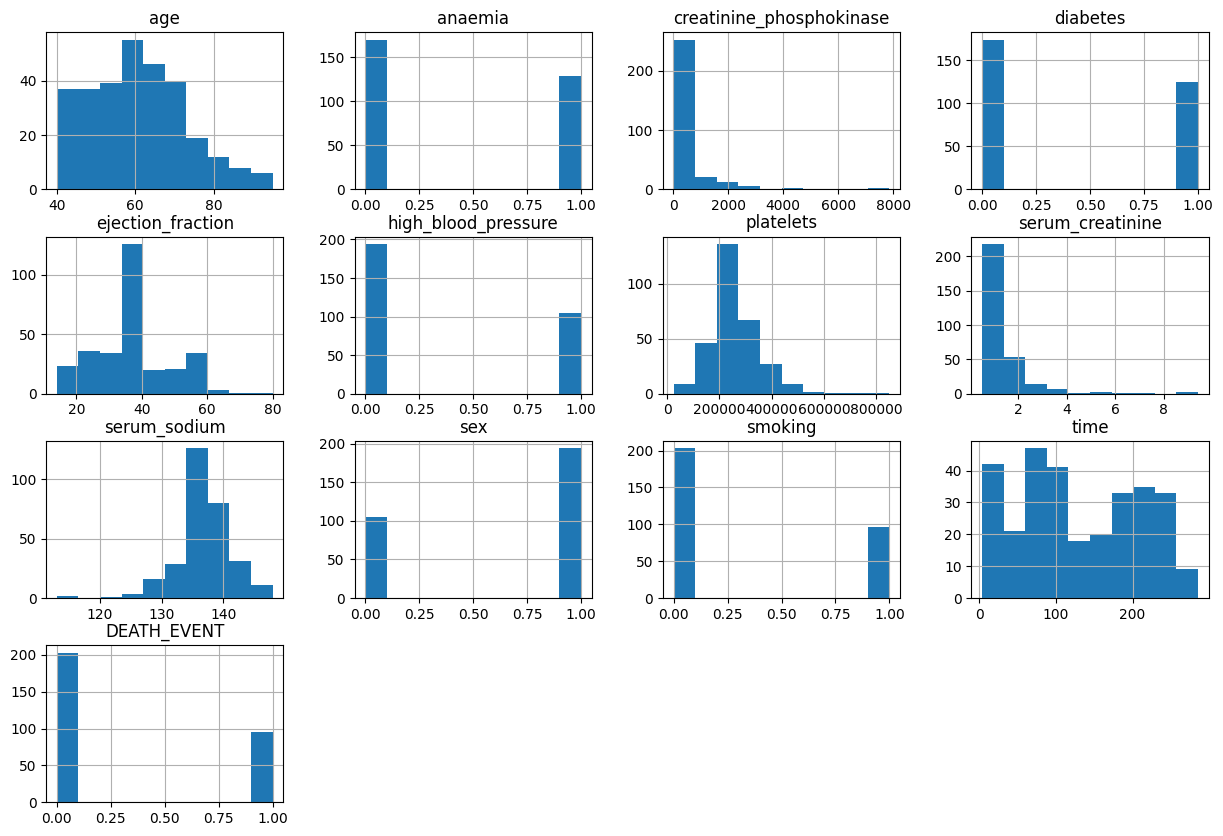

In [8]:
data_df.hist(figsize=(15,10))
plt.show()

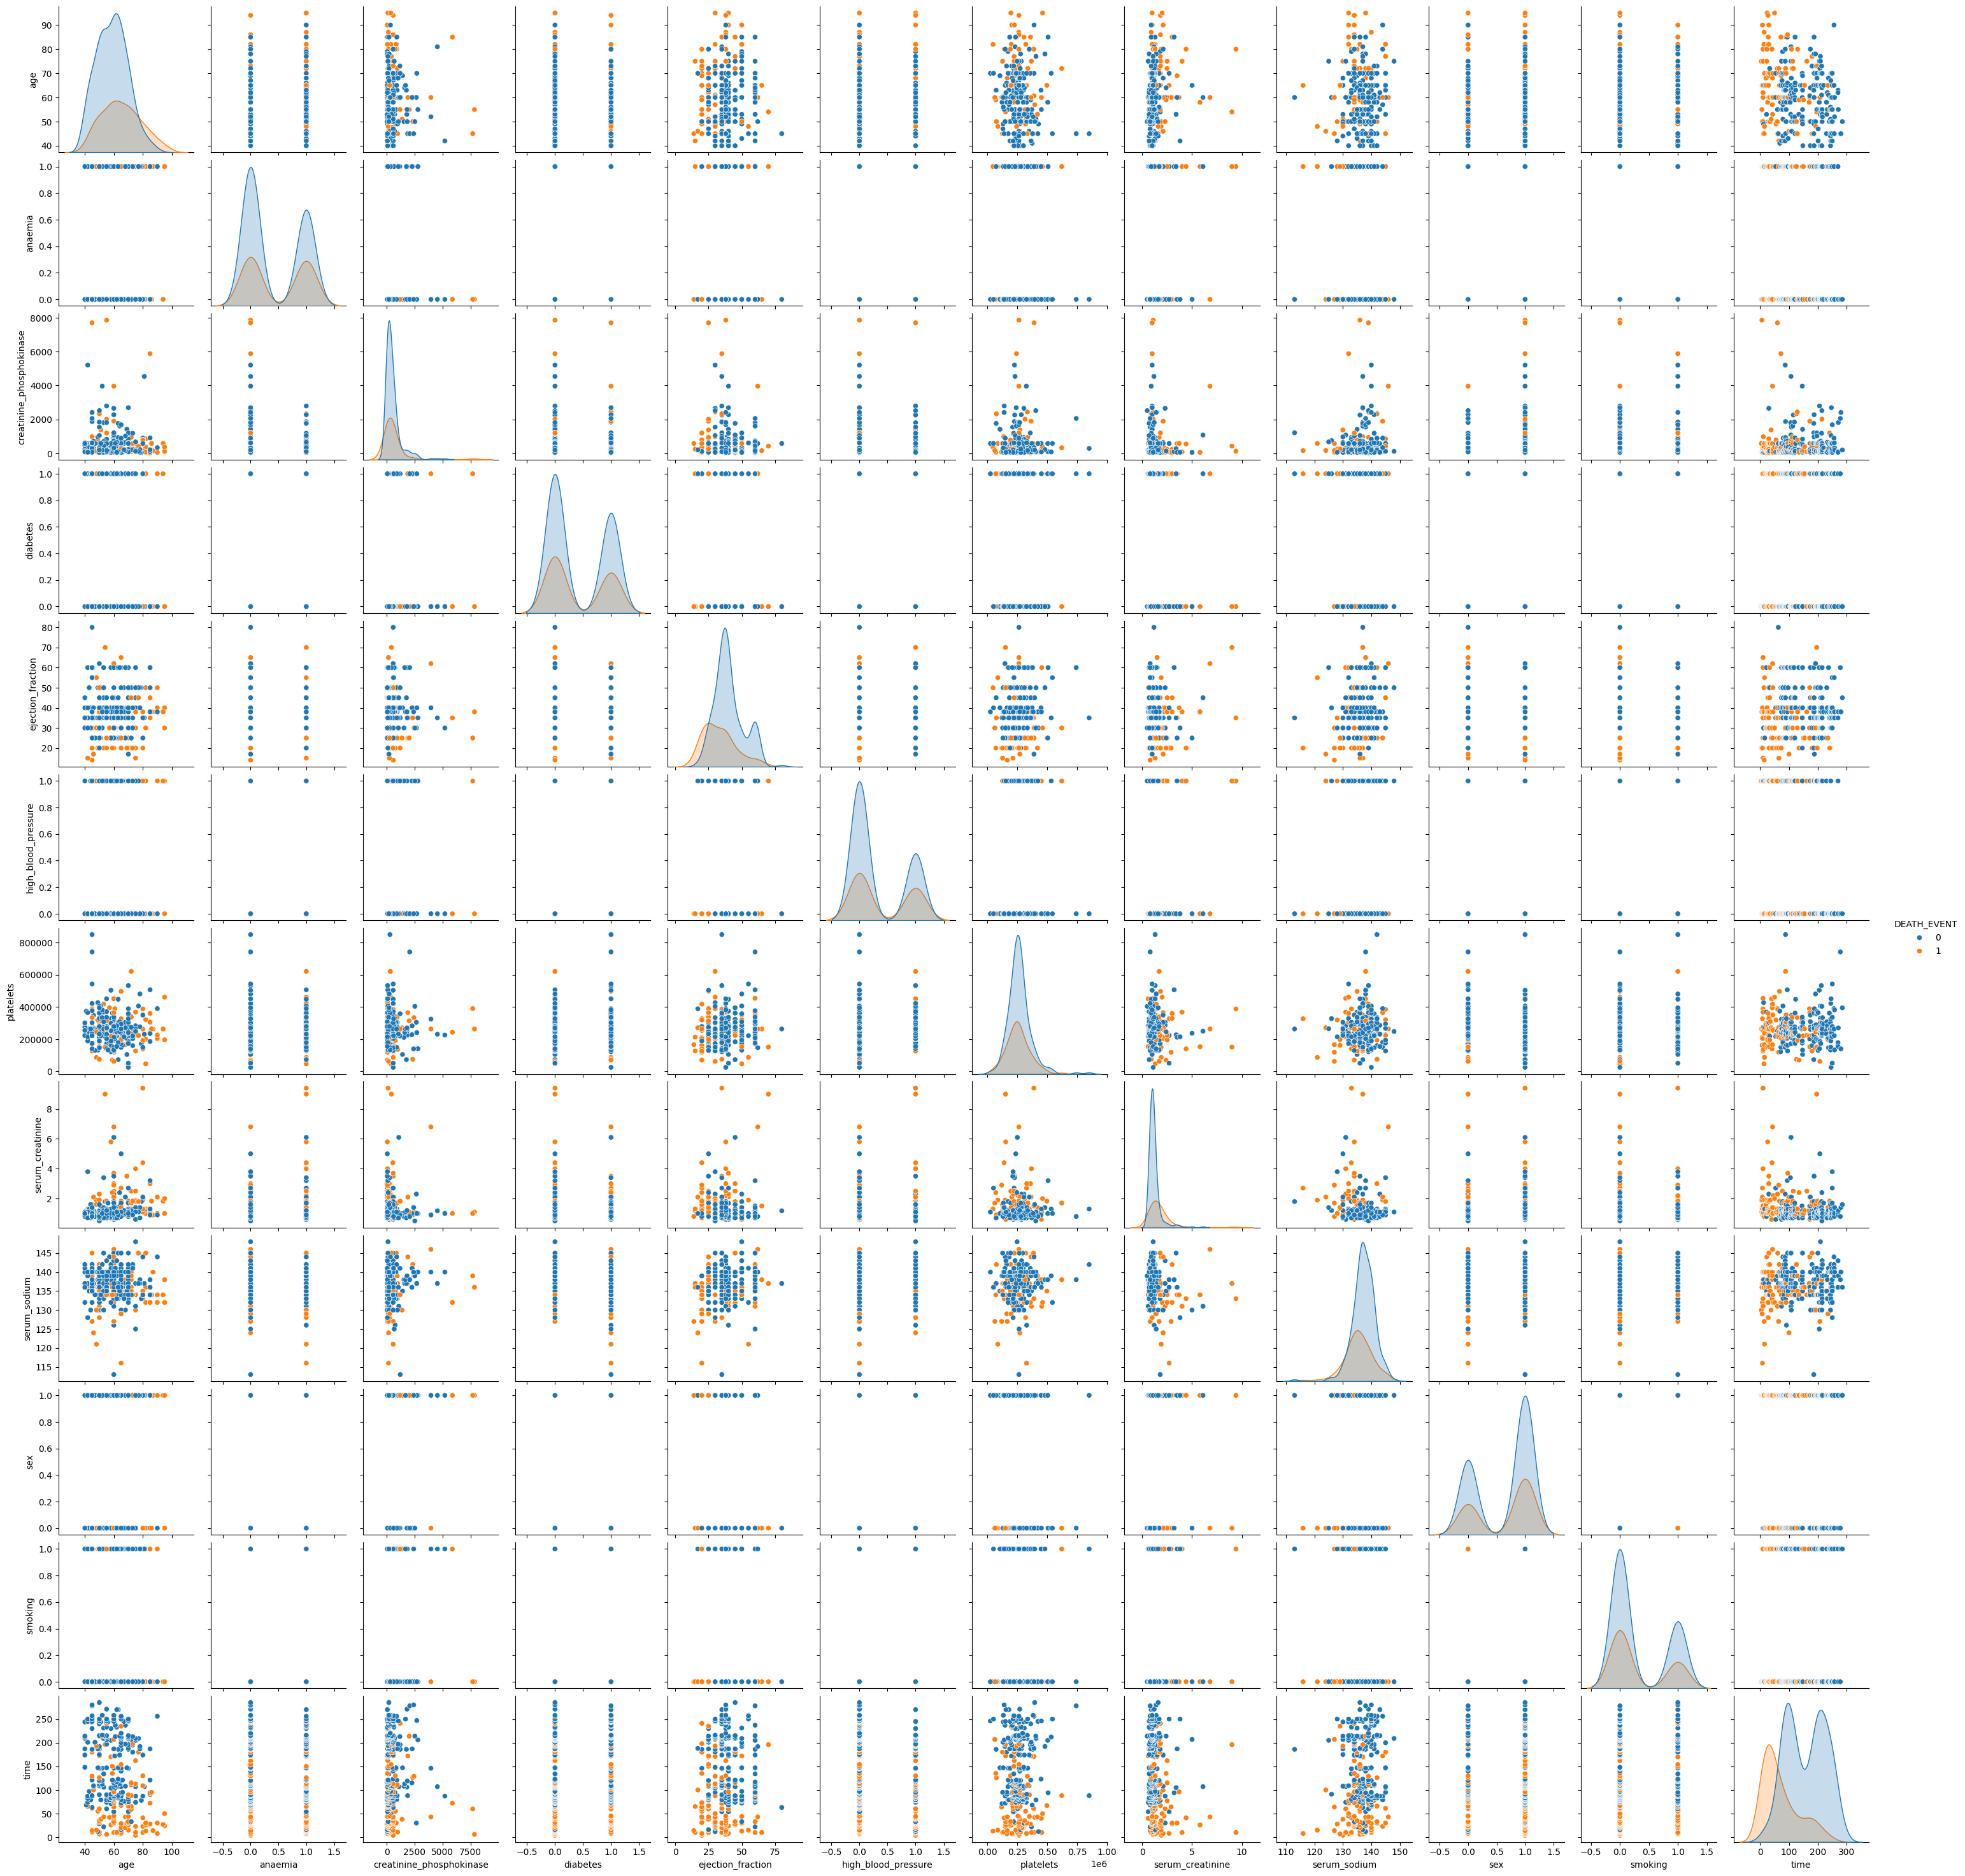

In [9]:
sns.pairplot(data_df, hue="DEATH_EVENT")
plt.show()

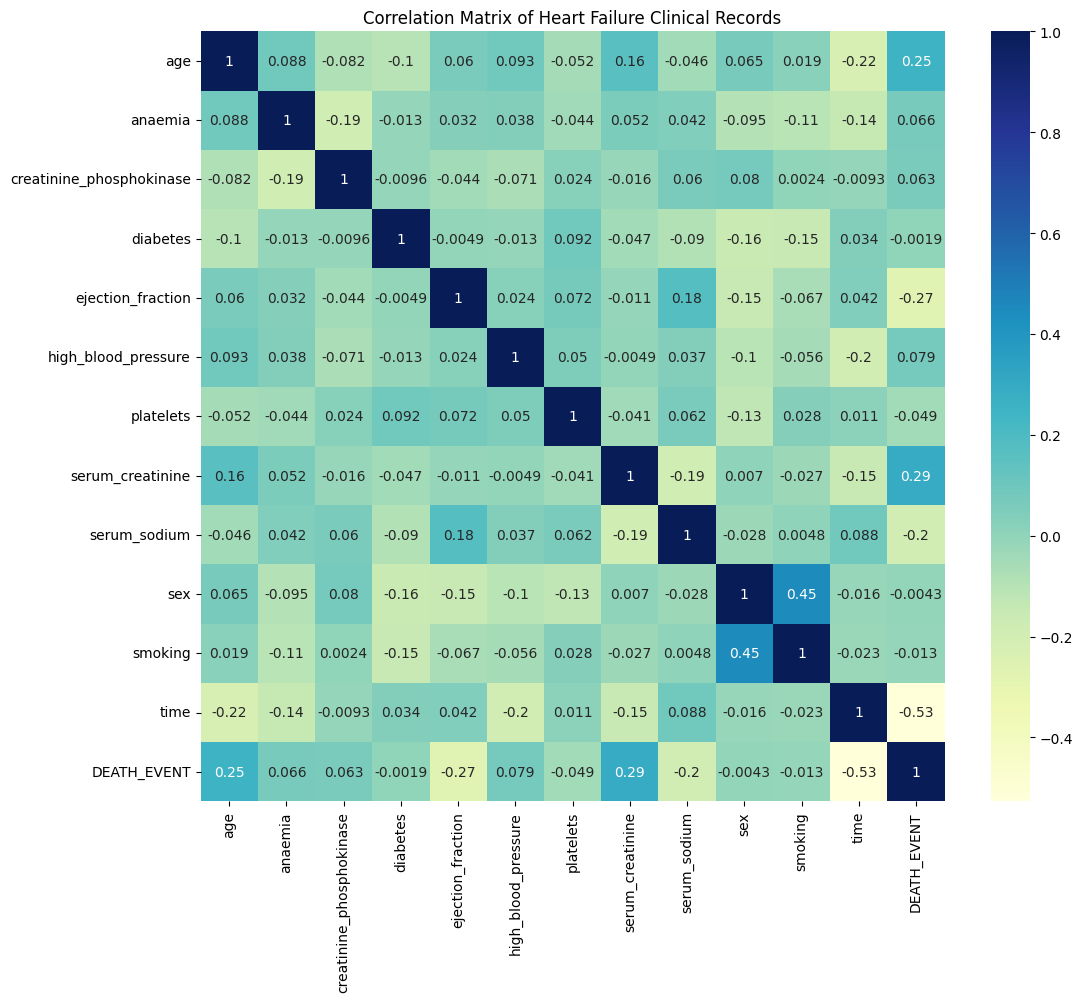

In [10]:
plt.figure(figsize=(12,10))

sns.heatmap(
    data_df.corr(),
    annot= True,
    cmap="YlGnBu"
)

plt.title("Correlation Matrix of Heart Failure Clinical Records")
plt.show()

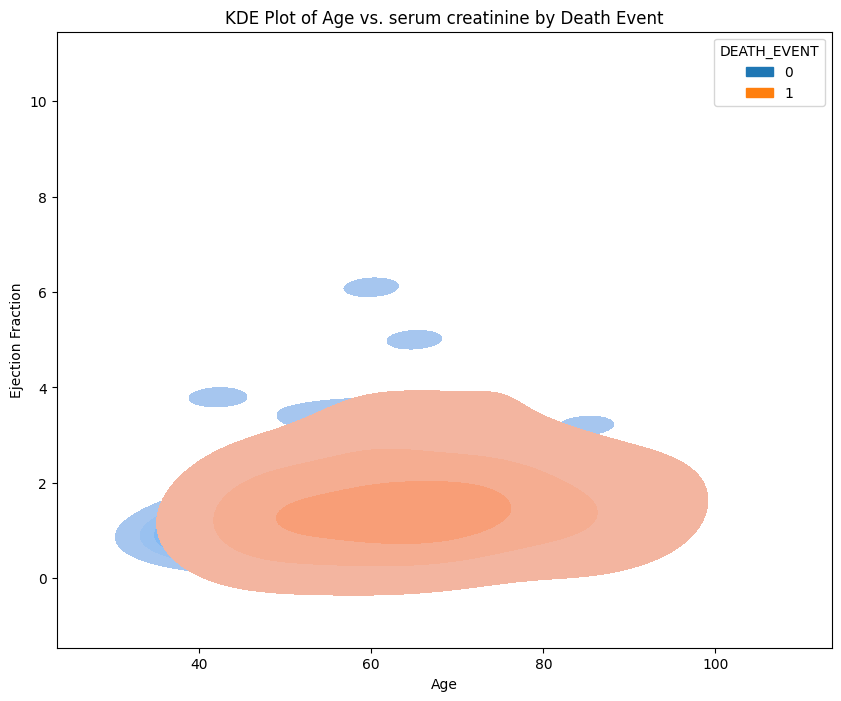

In [11]:
plt.figure(figsize=(10,8))

sns.kdeplot(
    x = data_df["age"],
    y = data_df["serum_creatinine"],
    hue = data_df["DEATH_EVENT"],
    fill = True
)

plt.title("KDE Plot of Age vs. serum creatinine by Death Event")
plt.xlabel("Age")
plt.ylabel("Ejection Fraction")

plt.show()

In [12]:
X = data_df.drop("DEATH_EVENT", axis=1)
y = data_df["DEATH_EVENT"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = SVC(kernel="sigmoid")
model.fit(X_train, y_train)

SVC(kernel='sigmoid')

In [16]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7666666666666667
